<a href="https://colab.research.google.com/github/ybae92/ybae92.github.io/blob/main/school-projects/Marketing-Campaign-Analysis/Marketing-Campaign-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS203 Final Project
Cotton, Flor, Kai, Yuna

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import psycopg2

In [ ]:
# Connect to your postgres DB
conn = psycopg2.connect(
dbname="project-marketing",
user="postgres",
password="VMware1!",
host="localhost",
port="5432"
)
# Open a cursor to perform database operations
cur = conn.cursor()

In [ ]:
df = pd.read_sql("SELECT * FROM marketing", conn)
df

C:\Users\YuNa\AppData\Local\Temp\ipykernel_37008\329456702.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM marketing", conn)


,campaignid,startdate,enddate,channel,impressions,clicks,leads,conversions,cost_usd,revenue_usd,roi
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86
...,...,...,...,...,...,...,...,...,...,...,...
9995,CAMP09996,2025-05-28,2025-06-03,Influencer,112030,1896,627,152,4491.36,12415.83,1.76
9996,CAMP09997,2025-12-31,2026-01-06,Search,177412,11529,2021,955,761.85,1214.01,0.59
9997,CAMP09998,2025-12-30,2026-01-07,Social,41892,4098,940,470,116.84,339.12,1.90
9998,CAMP09999,2025-05-20,2025-05-28,Social,141674,10697,1834,385,2885.00,6580.54,1.28


## Which channel generates the highest & lowest ROI?

In [ ]:
roi_query = """
    SELECT * FROM channel_roi_v;"""

roi_df = pd.read_sql(roi_query, conn)

roi_df

C:\Users\YuNa\AppData\Local\Temp\ipykernel_37008\514637888.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  roi_df = pd.read_sql(roi_query, conn)


,channel,avg_roi
0,Social,0.988
1,Display,0.999
2,Influencer,0.998
3,Search,1.013
4,Email,1.010


C:\Users\YuNa\AppData\Local\Temp\ipykernel_37008\3555409733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


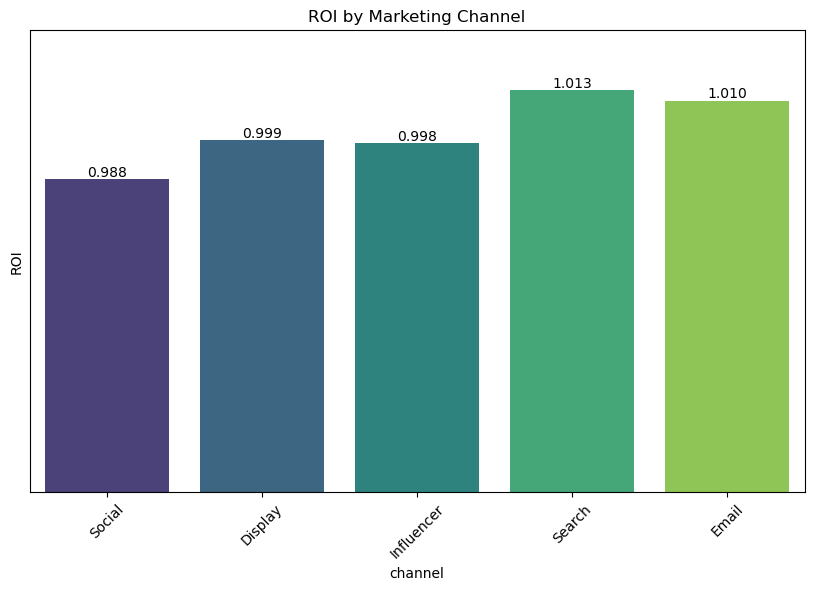

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=roi_df,
    x="channel",
    y="avg_roi",
    palette="viridis"
)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.3f}",
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("ROI by Marketing Channel")
plt.xlabel("channel")
plt.ylabel("ROI")
plt.ylim(0.90, 1.03)
plt.xticks(rotation=45)
plt.yticks([])
plt.show()


## Cost per channel


In [ ]:
cost_query = """
    SELECT * FROM channel_cost_v;"""

cost_df = pd.read_sql(cost_query, conn)

cost_df

C:\Users\YuNa\AppData\Local\Temp\ipykernel_37008\2074950582.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cost_df = pd.read_sql(cost_query, conn)


,channel,sum_cost
0,Social,4919999.25
1,Display,5343184.30
2,Influencer,5278787.92
3,Search,4916568.46
4,Email,5065029.98


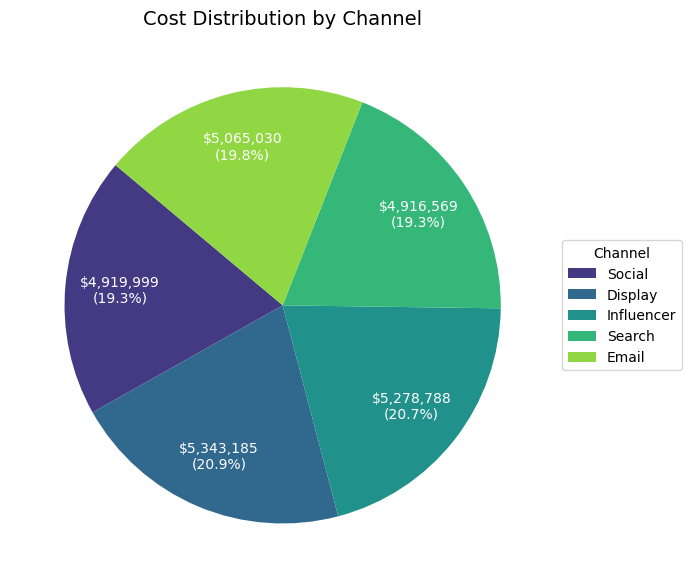

In [ ]:
plt.figure(figsize=(7,7))

total_cost = cost_df["sum_cost"].sum()

def autopct_format(pct):
    absolute = pct / 100 * total_cost
    return f"${absolute:,.0f}\n({pct:.1f}%)"

colors = sns.color_palette("viridis", len(cost_df))

wedges, texts, autotexts = plt.pie(
    cost_df["sum_cost"],
    labels=None,
    autopct=autopct_format,
    colors=colors,
    startangle=140,
    #explode=explode,
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10)

plt.legend(
    wedges,
    cost_df["channel"],
    title="Channel",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Cost Distribution by Channel", fontsize=14)
plt.tight_layout()
plt.show()

## Revenue per channel

In [ ]:
revenue_query = """
    SELECT * FROM channel_revenue_v;"""

revenue_df = pd.read_sql(revenue_query, conn)

revenue_df

C:\Users\YuNa\AppData\Local\Temp\ipykernel_37008\2470009235.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  revenue_df = pd.read_sql(revenue_query, conn)


,channel,sum_revenue
0,Social,9725024.70
1,Display,10715125.21
2,Influencer,10558118.99
3,Search,9897677.79
4,Email,10130542.61


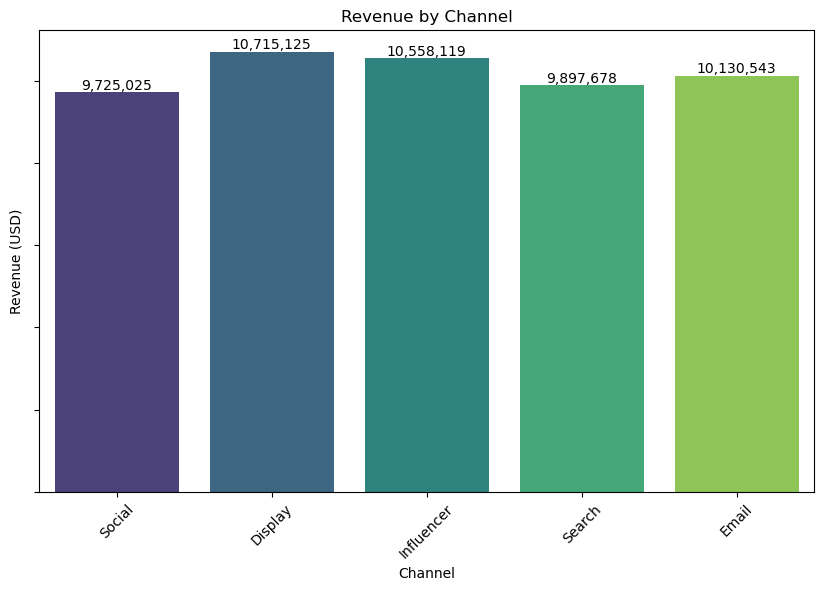

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=revenue_df,
    x="channel",
    y="sum_revenue",
    hue="channel",
    palette="viridis",
    legend=False
)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Revenue by Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.gca().set_yticklabels([])

plt.show()

## Which channel performs best? (e.g., Facebook, Google, Email, etc.)

In [ ]:
convers_sql = """SELECT * FROM channel_convers_v LIMIT 5;"""
convers_df = pd.read_sql(convers_sql, conn)

convers_df


C:\Users\YuNa\AppData\Local\Temp\ipykernel_37008\2685785101.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  convers_df = pd.read_sql(convers_sql, conn)


,channel,sum_convers
0,Social,1920020
1,Display,2057607
2,Influencer,2101198
3,Search,1951752
4,Email,2076423


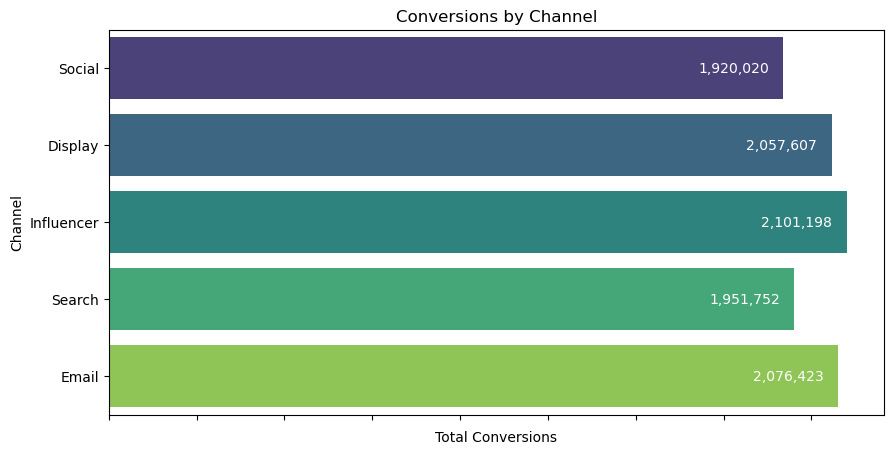

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=convers_df,
    y="channel",
    x="sum_convers",
    hue="channel",
    palette="viridis",
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():,.0f}",
        (p.get_width() * 0.98, p.get_y() + p.get_height() / 2),
        ha="right",
        va="center",
        color = "white"
    )

plt.title("Conversions by Channel")
plt.xlabel("Total Conversions")
plt.ylabel("Channel")
plt.gca().set_xticklabels([])


plt.show()